In [1]:
import os, cv2, json, glob, joblib
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from skimage.feature import hog, local_binary_pattern
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from collections import Counter


In [2]:
ANN_JSON    = '2D-on-2D_annotations_export (9).json'
TRAIN_IMG   = '../train'
TEST_IMG    = '../test'
TEST_PRED   = 'test_pred'
SUB_SAMPLE  = 'sample_submission.csv'
SUB_OUT     = 'submission_classic_new.csv'

MIN_AREA    = 10000
MORPH_KSIZE = 9
MORPH_KERNEL_SIZE = 9


# descriptor params
REF_SIZE    = (128,128)
HOG_PARAMS  = dict(orientations=9,
                   pixels_per_cell=(16,16),
                   cells_per_block=(2,2),
                   block_norm='L2-Hys',
                   feature_vector=True)
LBP_P       = 8
LBP_R       = 1
LBP_METHOD  = 'uniform'
HSV_BINS    = [50,50]   # H & V channels


# SVM params
C_PARAM     = 1.0       # regularization

In [3]:
def segment_pieces_simple(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    # Estimate background from border median
    border = np.hstack([
        gray[0, :], gray[-1, :], gray[:, 0], gray[:, -1]
    ])
    bg_val = int(np.median(border))

    # Absolute difference + Otsu
    diff = cv2.absdiff(gray, np.full_like(gray, bg_val))
    _, mask = cv2.threshold(diff, 0, 255,
                            cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological closing + dilation
    kern = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,
                                     (MORPH_KERNEL_SIZE, MORPH_KERNEL_SIZE))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kern, iterations=3)
    mask = cv2.dilate(mask, kern, iterations=2)

    # Find contours → list of (mask, bbox)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    pieces = []
    boxes  = []
    for c in contours:
        if cv2.contourArea(c) < MIN_AREA: 
            continue
        x,y,w,h = cv2.boundingRect(c)
        boxes.append((x,y,w,h))
    return boxes




# Color data (RGB tuples)
color_data = {
    "Amandina": [(180, 172, 152), (143, 96, 54), (195, 179, 128)],
    "Arabia": [(101, 61, 38), (50, 30, 23)],
    "Comtesse": [(225, 225, 217), (186, 172, 137)],
    "Crème Brulée": [(197, 188, 159), (148, 75, 32)],
    "Jelly Black": [(34, 23, 21), (70, 83, 125)],
    "Jelly Milk": [(86, 49, 30), (142, 135, 153)],
    "Jelly White": [(202, 193, 162), (228, 229, 223)],
    "Noblesse": [(138, 92, 59), (61, 37, 27)],
    "Noir Authentique": [(67, 37, 27), (118, 82, 58)],
    "Passion au Lait": [(94, 56, 35), (181, 175, 143), (134, 110, 112)],
    "Stracciatella": [(81, 53, 40), (139, 137, 142)],
    "Tentation Noir": [(75, 45, 35), (42, 30, 32), (103, 79, 79)],
    "Triangolo": [(99, 52, 32), (130, 97, 90), (67, 37, 27)],
}
replacement_color = (183, 181, 184)  # RGB



# 2) Mask creation functions
def create_rgb_mask(img_rgb, color_data, tol=(15,15,15)):
    mask = np.zeros(img_rgb.shape[:2], dtype=np.uint8)
    for colors in color_data.values():
        for c in colors:
            diff = np.abs(img_rgb.astype(int) - np.array(c)[None,None,:])
            mask[np.all(diff <= tol, axis=-1)] = 255
    return mask

def create_hsv_mask(img_bgr, color_data, tol=(5,40,30)):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for colors in color_data.values():
        for c in colors:
            bgr = np.uint8([[[c[2],c[1],c[0]]]])
            hsv_ref = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)[0,0]
            diff = np.abs(hsv.astype(int) - hsv_ref[None,None,:])
            dh = np.minimum(diff[:,:,0], 180 - diff[:,:,0])
            ds, dv = diff[:,:,1], diff[:,:,2]
            mask[(dh<=tol[0])&(ds<=tol[1])&(dv<=tol[2])] = 255
    return mask

def preprocess(img_bgr):
    """Replace background by replacement_color."""
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    m_rgb   = create_rgb_mask(img_rgb, color_data)
    m_hsv   = create_hsv_mask(img_bgr,   color_data)
    fg_mask = cv2.bitwise_or(m_rgb, m_hsv)
    out     = img_rgb.copy()
    out[fg_mask==0] = replacement_color
    return out

def otsu_mask(preproc_rgb):
    """Compute Otsu mask on preprocessed RGB."""
    gray = cv2.cvtColor(preproc_rgb, cv2.COLOR_RGB2GRAY)
    _, m = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    # invert so chocolates=white
    mask = cv2.bitwise_not(m)

    # morphology
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask = cv2.erode(mask, kernel, iterations=1)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9,9))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    return mask

def segment_pieces(img_bgr):

    otsu_mask = otsu_mask(preprocess(img_bgr))

    # Find contours → list of (mask, bbox)
    contours, _ = cv2.findContours(otsu_mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    boxes  = []
    for c in contours:
        if cv2.contourArea(c) < MIN_AREA: 
            continue
        x,y,w,h = cv2.boundingRect(c)
        boxes.append((x,y,w,h))
    return boxes


def draw_boxes(img_bgr, mask):
    vis = img_bgr.copy()
    cnts,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for c in cnts:
        if cv2.contourArea(c) < MIN_AREA:
            continue
        x,y,w,h = cv2.boundingRect(c)
        cv2.rectangle(vis, (x,y),(x+w,y+h), (255,0,255), 2)
    return vis

 


In [4]:
def extract_descriptor(patch):
    gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, REF_SIZE)
    # HOG
    h = hog(gray, **HOG_PARAMS)
    # LBP
    lbp = local_binary_pattern(gray, LBP_P, LBP_R, LBP_METHOD)
    lbp_hist,_ = np.histogram(lbp.ravel(), bins=LBP_P+2, range=(0,LBP_P+2))
    lbp_hist    = lbp_hist.astype(float)
    lbp_hist   /= (lbp_hist.sum()+1e-6)
    # HSV hist (H & V channels)
    hsv = cv2.cvtColor(patch, cv2.COLOR_BGR2HSV)
    h_hist = cv2.calcHist([hsv],[0],None,[HSV_BINS[0]],[0,180]).flatten()
    v_hist = cv2.calcHist([hsv],[2],None,[HSV_BINS[1]],[0,256]).flatten()
    h_hist/= (h_hist.sum()+1e-6)
    v_hist/= (v_hist.sum()+1e-6)
    return np.hstack([h, lbp_hist, h_hist, v_hist])

In [5]:
print("Loading annotations…")
with open(ANN_JSON) as f:
    ann = json.load(f)

# map image filename → list of bboxes + class id
gt = {}
for img in ann['images']:
    fname = img['image']         # 'L1000768.JPG'
    items = []
    for obj in img['annotations']:
        cls_name = obj['class']  # e.g. 'Comtesse'
        # find the index of the class dict whose 'name' matches
        cls_idx = next(
            i for i, c in enumerate(ann['classes'])
            if c['name'] == cls_name
        )
        bb = obj['boundingBox']
        # Round or int-cast the floats to get pixel coordinates
        x, y = int(round(bb['x'])), int(round(bb['y']))
        w, h = int(round(bb['width'])), int(round(bb['height']))
        items.append((cls_idx, x, y, w, h))

    gt[fname] = items
    
X_train, y_train = [], []
print("Extracting descriptors from train bboxes…")
for fname, objects in tqdm(gt.items()):
    img = cv2.imread(os.path.join(TRAIN_IMG, fname))
    for cls,x,y,w,h in objects:
        patch = img[y:y+h, x:x+w]
        desc = extract_descriptor(patch)
        X_train.append(desc)
        y_train.append(cls)

X_train = np.stack(X_train)
y_train = np.array(y_train)


Loading annotations…
Extracting descriptors from train bboxes…


  0%|          | 0/45 [00:00<?, ?it/s]

100%|██████████| 45/45 [00:04<00:00, 10.75it/s]


In [6]:

print("Training SVM…")
clf = make_pipeline(StandardScaler(), svm.LinearSVC(C=C_PARAM, max_iter=5000))
clf.fit(X_train, y_train)
joblib.dump(clf, 'svm_choco.joblib')


Training SVM…


['svm_choco.joblib']

In [7]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import svm

print("Training calibrated SVM…")
base = svm.LinearSVC(C=C_PARAM, max_iter=5000)
clf = make_pipeline(
    StandardScaler(),
    CalibratedClassifierCV(base, cv=5)   # 5-fold to train probabilities
)
clf.fit(X_train, y_train)
joblib.dump(clf, 'svm_choco_proba.joblib')


Training calibrated SVM…


['svm_choco_proba.joblib']

In [8]:
TEST_IMG    = '../test'
PREPROC_DIR = Path('preprocessed')
MASK_DIR    = Path('masks')
TEST_PRED   = Path('test_pred')
SUB_SAMPLE  = 'sample_submission.csv'
SUB_OUT     = 'submission_svm_colorrepl.csv'

os.makedirs(PREPROC_DIR, exist_ok=True)
os.makedirs(MASK_DIR,    exist_ok=True)
os.makedirs(TEST_PRED,   exist_ok=True)



sample = pd.read_csv(SUB_SAMPLE)

out    = sample.copy()

class_names = [c['name'] for c in ann['classes']]

col_to_idx = {
    col: class_names.index(col)
    for col in sample.columns
    if col != 'id'
}


for idx, row in tqdm(sample.iterrows(), total=len(sample)):
    img_id = int(row['id'])
    fn     = f"L{img_id}.JPG"
    path   = Path(TEST_IMG)/fn
    img    = cv2.imread(str(path))
    if img is None:
        path = Path(TEST_IMG)/f"L{img_id}.jpg"
        img  = cv2.imread(str(path))
    if img is None:
        print("Missing", fn); continue

    # 1) Preprocess (color replace) -------------
    preproc_path = PREPROC_DIR/fn
    if preproc_path.exists():
        preproc = cv2.cvtColor(cv2.imread(str(preproc_path)), cv2.COLOR_BGR2RGB)
    else:
        preproc = preprocess(img)
        # save as BGR
        cv2.imwrite(str(preproc_path),
                    cv2.cvtColor(preproc, cv2.COLOR_RGB2BGR))

    # 2) Otsu mask  -----------------------------
    mask_path = MASK_DIR/f"{img_id}.png"
    if mask_path.exists():
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    else:
        mask = otsu_mask(preproc)
        cv2.imwrite(str(mask_path), mask)

    # Find contours → list of (mask, bbox)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    boxes  = []
    for c in contours:
        if cv2.contourArea(c) < MIN_AREA: 
            continue
        x,y,w,h = cv2.boundingRect(c)
        boxes.append((x,y,w,h))

    #print("Found", len(boxes), "pieces in", fn)
    cnts  = Counter()
    vis   = img.copy()
    for (x,y,w,h) in boxes:
        patch = img[y:y+h, x:x+w]
        desc  = extract_descriptor(patch)
        cls   = clf.predict(desc.reshape(1,-1))[0]
        cnts[cls] += 1
        cv2.rectangle(vis,(x,y),(x+w,y+h),(0,255,0),2)
        name = class_names[cls]
        cv2.putText(vis, name, (x,y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 3, (0,255,0),2)

    # 3) Draw boxes on original -----------------
    #vis   = draw_boxes(img, mask)

    # 4) Count & fill submission ---------------
    #cnts  = Counter()
    #cnts.update(1 for c in cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]
    #            if cv2.contourArea(c) >= MIN_AREA)
    #for col, cls_i in col_to_idx.items():
    #    out.at[idx, col] = cnts.get(cls_i, 0)

    for col, cls_idx in col_to_idx.items():
        out.at[idx, col] = cnts.get(cls_idx, 0)

    # 5) Save visualization ---------------------
    cv2.imwrite(str(TEST_PRED/fn), vis)

# 6) Save submission --------------------------
out.to_csv(SUB_OUT, index=False)
print("Done →", SUB_OUT)


""""


print("Inferring on test images…")
for idx, row in tqdm(sample.iterrows(), total=len(sample)):
    fn  = f"L{row['id']}.JPG"
    path= Path(TEST_IMG)/fn
    img = cv2.imread(str(path))
    boxes = segment_pieces(img)
    print("Found", len(boxes), "pieces in", fn)
    cnts  = Counter()
    vis   = img.copy()
    for (x,y,w,h) in boxes:
        patch = img[y:y+h, x:x+w]
        desc  = extract_descriptor(patch)
        cls   = clf.predict(desc.reshape(1,-1))[0]
        cnts[cls] += 1
        cv2.rectangle(vis,(x,y),(x+w,y+h),(255,0,255),2)
        name = class_names[cls]
        cv2.putText(vis, name, (x,y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 3, (255,0,255),2)
    for col, cls_idx in col_to_idx.items():
        out.at[idx, col] = cnts.get(cls_idx, 0)

    cv2.imwrite(str(Path(TEST_PRED)/fn), vis)

out.to_csv(SUB_OUT, index=False)
print("Done →", SUB_OUT, "visuals in", TEST_PRED)
"""

  1%|          | 2/180 [00:49<1:13:19, 24.72s/it]


KeyboardInterrupt: 

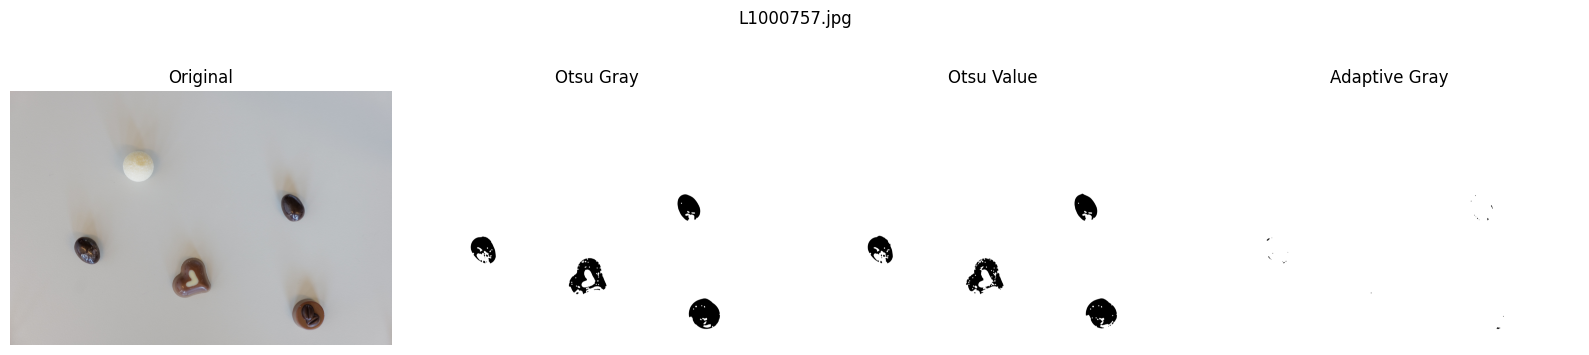

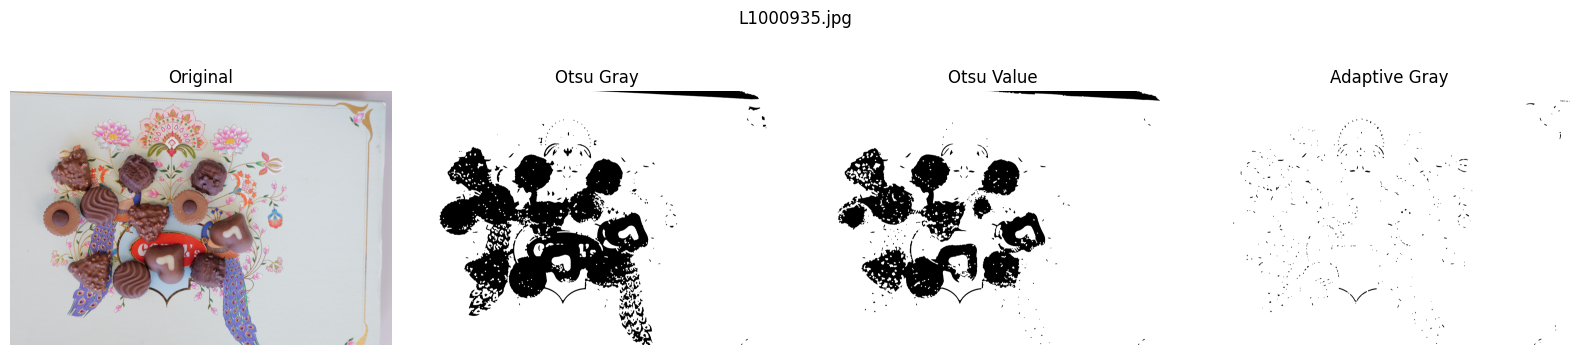

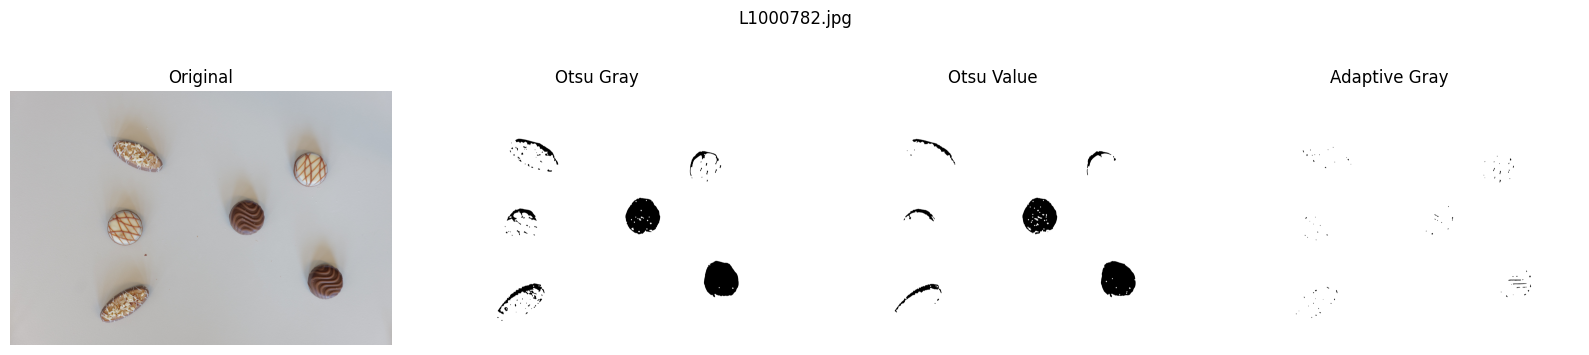

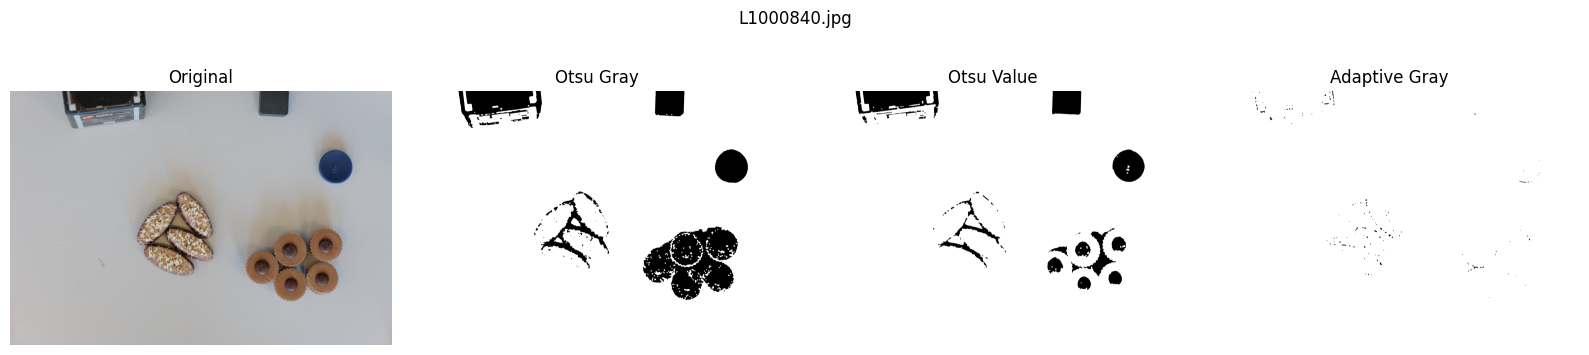

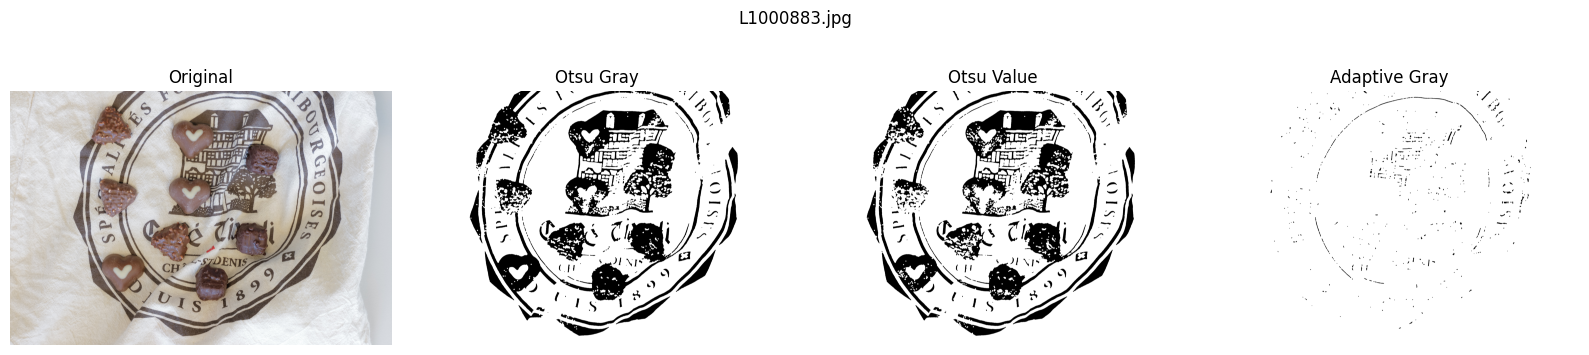

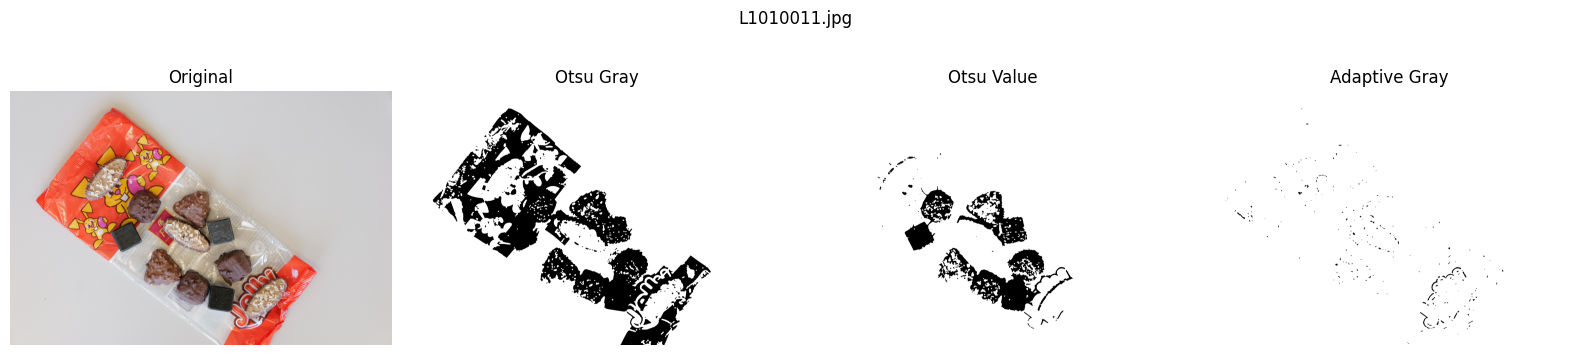

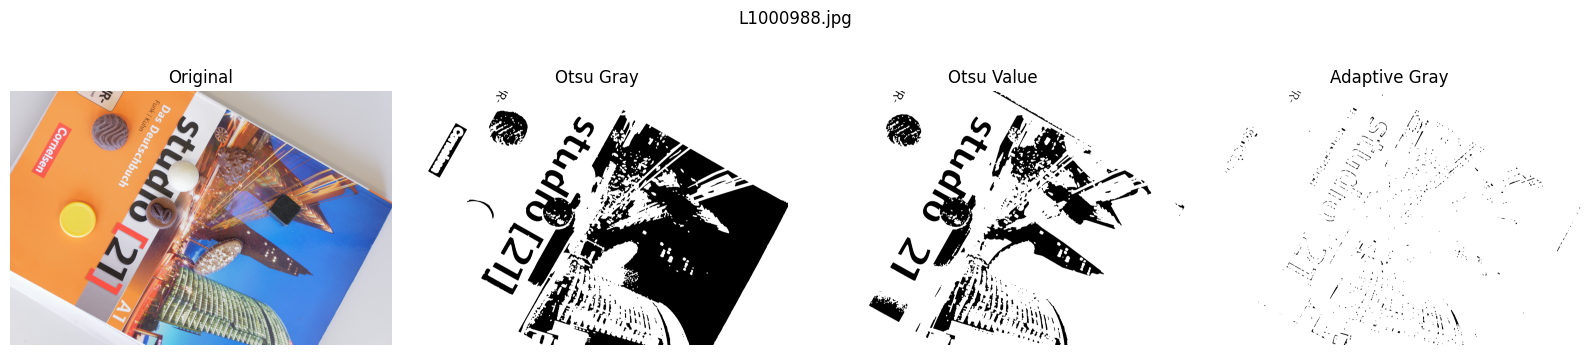

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# List of test images to process
TEST_DIR = Path('test/test')
test_files = [
    "L1000757.jpg", "L1000935.jpg", "L1000782.jpg",
    "L1000840.jpg", "L1000883.jpg", "L1010011.jpg", "L1000988.jpg"
]

# Segmentation functions
def otsu_gray(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return mask

def otsu_v(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    _, mask = cv2.threshold(hsv[:, :, 2], 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return mask

def adaptive_gray(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # blockSize must be odd, C is constant subtracted
    mask = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                 cv2.THRESH_BINARY, blockSize=51, C=5)
    return mask

def refine_mask(mask):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9,9))
    m = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    m = cv2.dilate(m, kernel, iterations=2)
    return m

# Methods to apply
methods = [
    ("Otsu Gray", otsu_gray),
    ("Otsu Value", otsu_v),
    ("Adaptive Gray", adaptive_gray),
]

# Process and plot
for fn in test_files:
    img_path = TEST_DIR / fn
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    
    # Compute masks
    masks = []
    for name, fn_seg in methods:
        m = fn_seg(img)
        m_ref = refine_mask(m)
        masks.append((name, m_ref))
    
    # Plot original + each mask
    n = len(masks) + 1
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")
    axes[0].axis('off')
    
    for i, (name, mask) in enumerate(masks, start=1):
        axes[i].imshow(mask, cmap='gray')
        axes[i].set_title(name)
        axes[i].axis('off')
    
    fig.suptitle(fn)
    plt.tight_layout()
    plt.show()


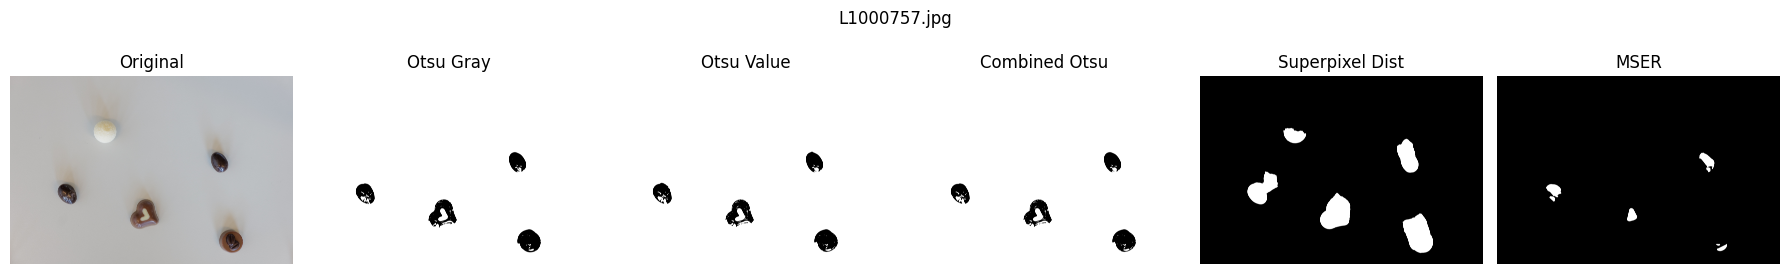

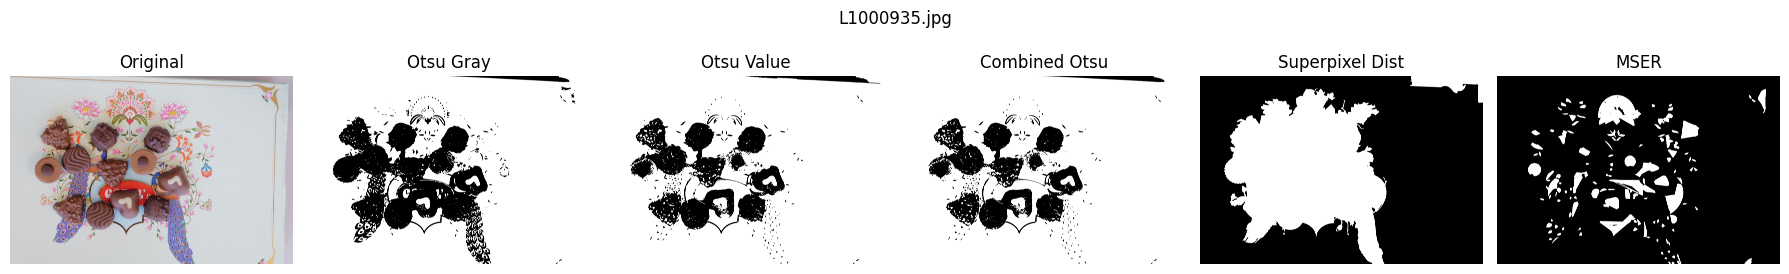

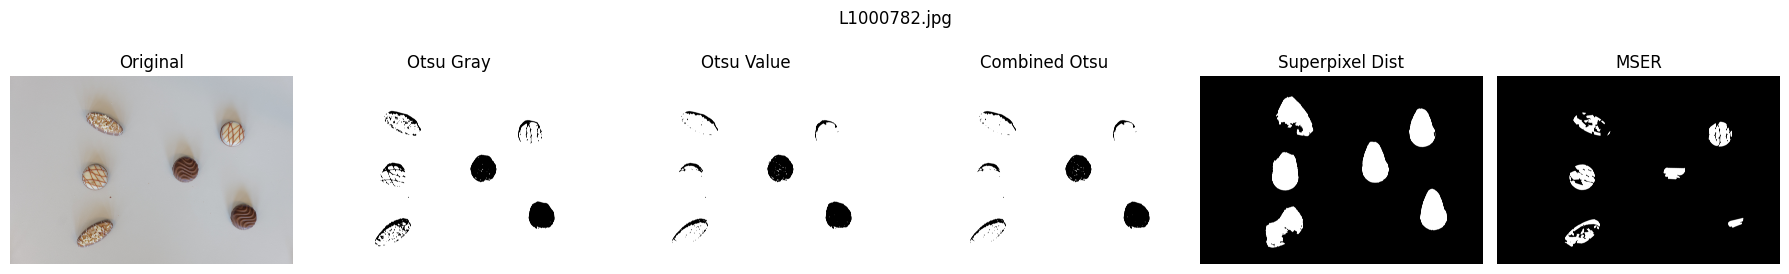

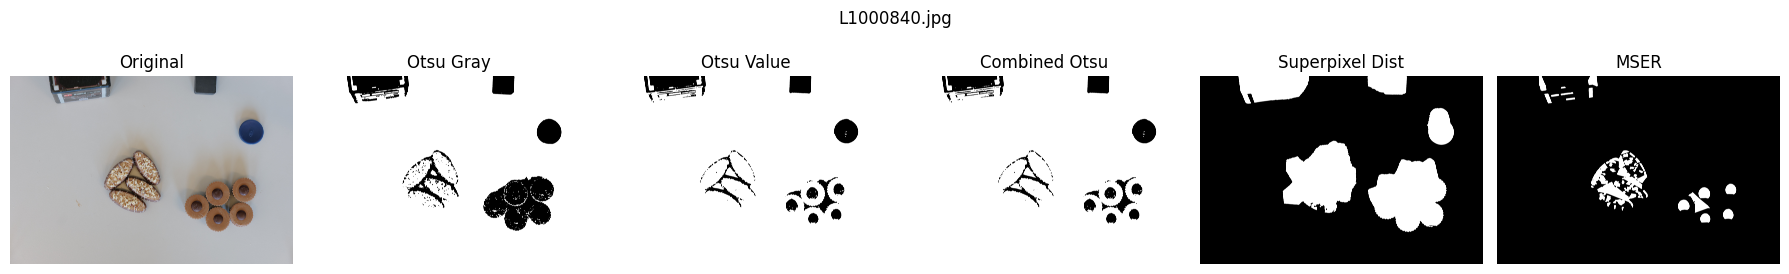

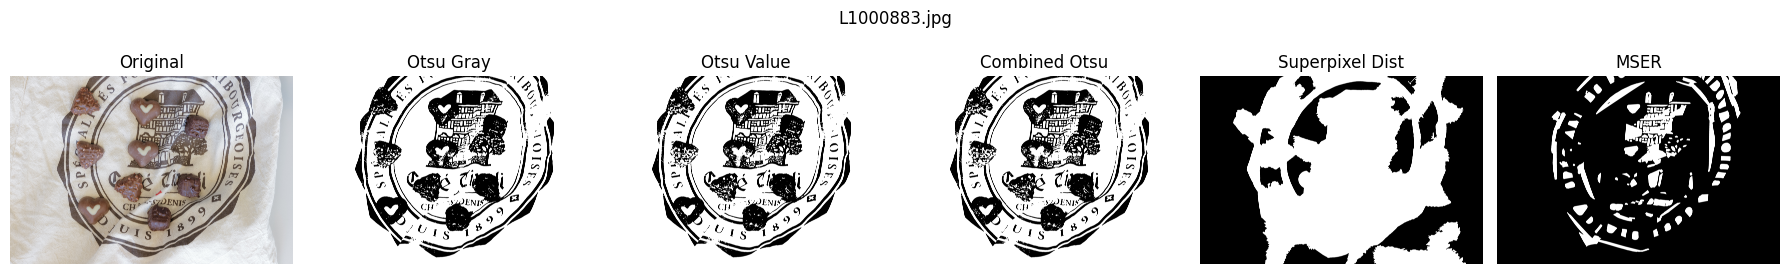

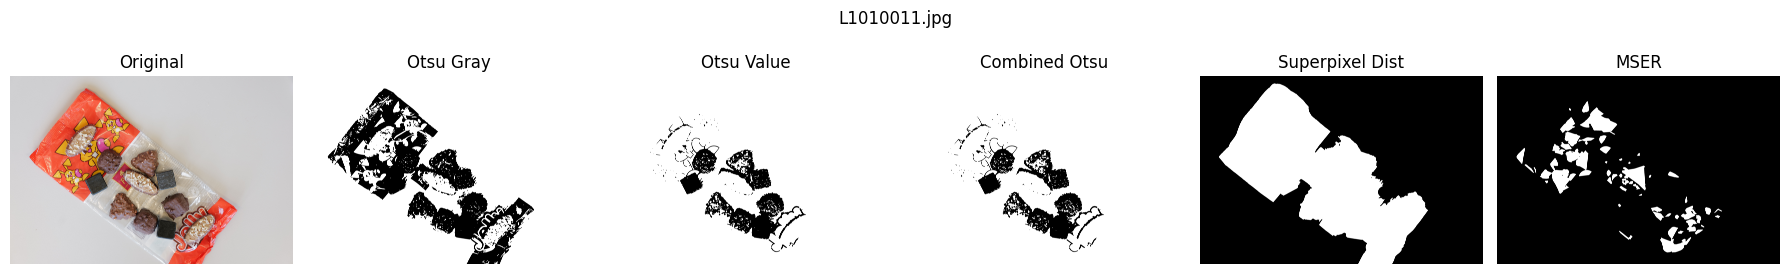

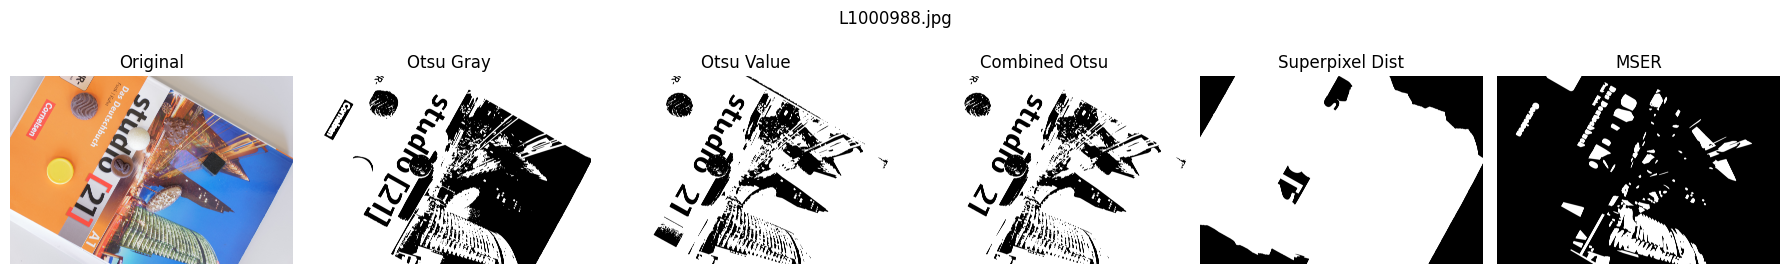

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.segmentation import slic

# 1) Configuration
TEST_DIR = Path('test/test')
test_files = [
    "L1000757.jpg", "L1000935.jpg", "L1000782.jpg",
    "L1000840.jpg", "L1000883.jpg", "L1010011.jpg", "L1000988.jpg"
]

# 2) Segmentation methods

def otsu_gray(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, m = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return m

def otsu_value(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    _, m = cv2.threshold(hsv[:,:,2], 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return m

def combined_otsu(img):
    m1 = otsu_gray(img)
    m2 = otsu_value(img)
    return cv2.bitwise_or(m1, m2)

def adaptive_gray(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    m = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY, blockSize=51, C=5)
    return m

def superpixel_bg_dist(img, n_segments=200, dist_thresh=20.0):
    # convert to Lab
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    # compute border median color
    h, w = lab.shape[:2]
    border = np.vstack([lab[0], lab[-1], lab[:,0], lab[:,-1]]).reshape(-1,3)
    bg_med = np.median(border, axis=0)
    # superpixels
    segments = slic(img, n_segments=n_segments, compactness=10, start_label=1)
    mask = np.zeros(h*w, dtype=np.uint8)
    lab_flat = lab.reshape(-1,3)
    seg_flat = segments.reshape(-1)
    for seg_id in np.unique(seg_flat):
        coords = np.where(seg_flat == seg_id)[0]
        mean_col = lab_flat[coords].mean(axis=0)
        if np.linalg.norm(mean_col - bg_med) > dist_thresh:
            mask[coords] = 255
    return mask.reshape(h,w)

def mser_regions(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mser = cv2.MSER_create(min_area=1000, max_area=50000)
    regions, _ = mser.detectRegions(gray)
    mask = np.zeros_like(gray)
    for reg in regions:
        cv2.fillPoly(mask, [reg.reshape(-1,1,2)], 255)
    return mask

def refine_mask(mask):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9,9))
    m = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    m = cv2.dilate(m, kernel, iterations=1)
    return m

methods = [
    ("Otsu Gray",        otsu_gray),
    ("Otsu Value",       otsu_value),
    ("Combined Otsu",    combined_otsu),
    ("Superpixel Dist",  superpixel_bg_dist),
    ("MSER",             mser_regions),
]

# 3) Process & Plot
for fname in test_files:
    img_path = TEST_DIR/fname
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Could not load {fname}")
        continue

    plt.figure(figsize=(18, 3))
    plt.subplot(1, len(methods)+1, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis('off')

    for i, (title, fn_seg) in enumerate(methods, start=2):
        raw = fn_seg(img)
        refined = refine_mask(raw)
        plt.subplot(1, len(methods)+1, i)
        plt.imshow(refined, cmap='gray')
        plt.title(title)
        plt.axis('off')

    plt.suptitle(fname)
    plt.tight_layout()
    plt.show()


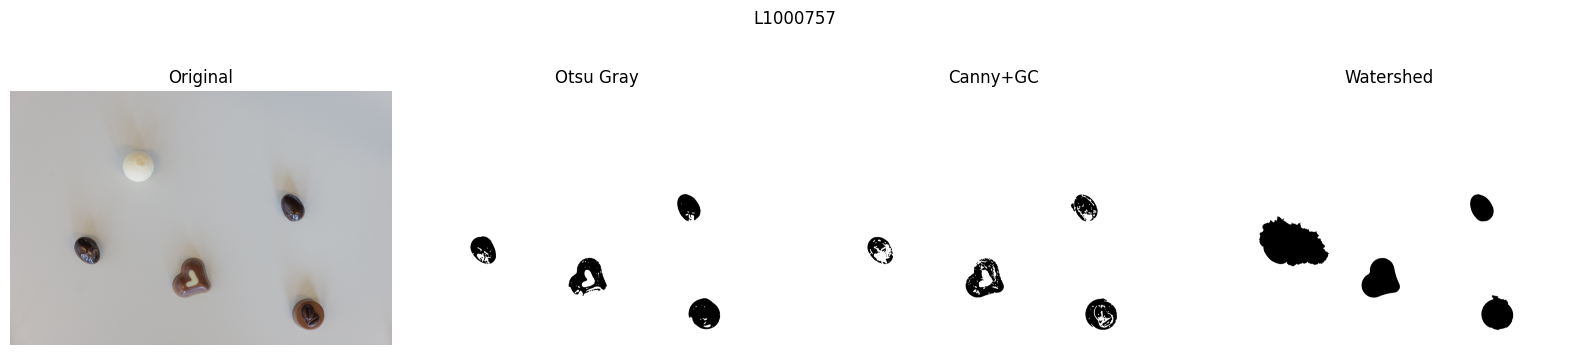

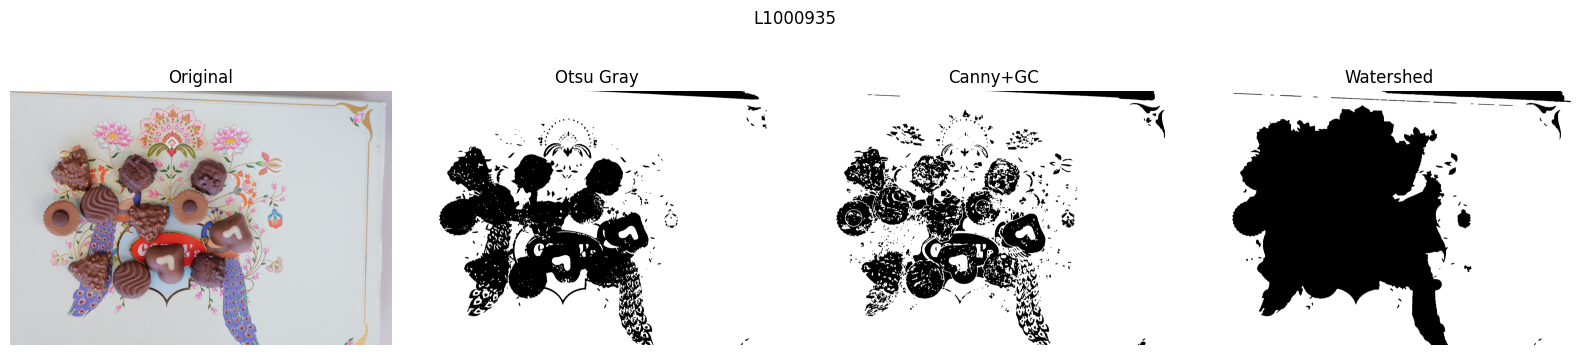

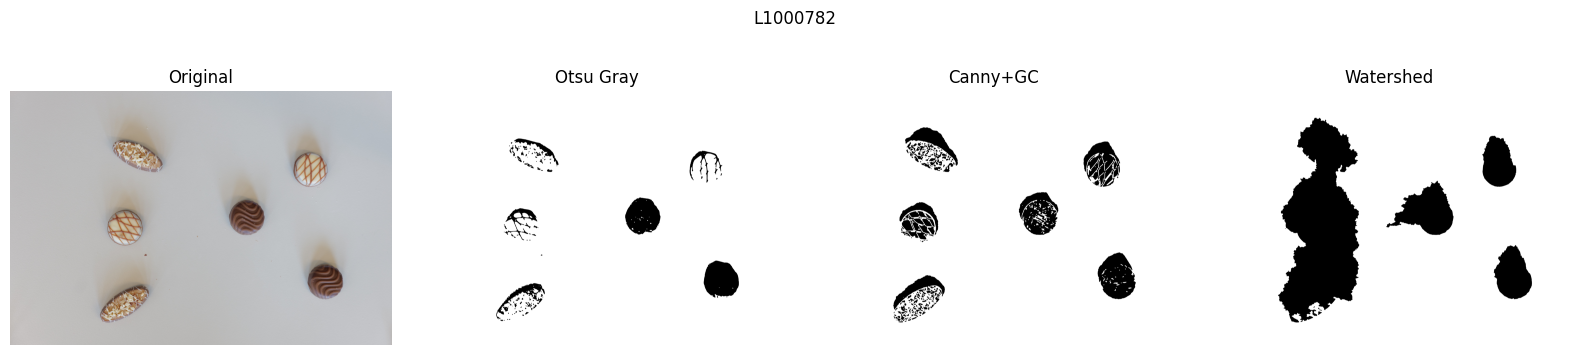

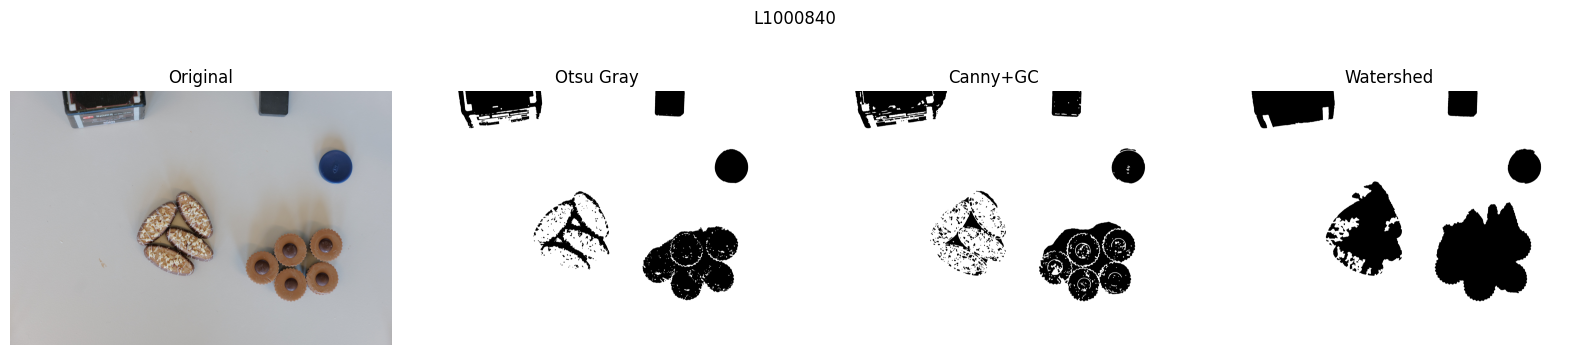

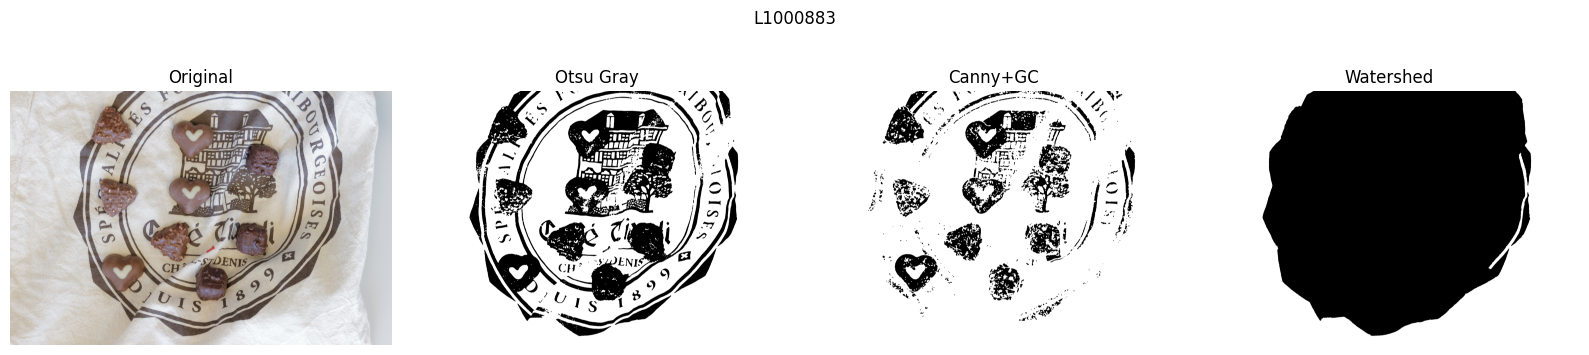

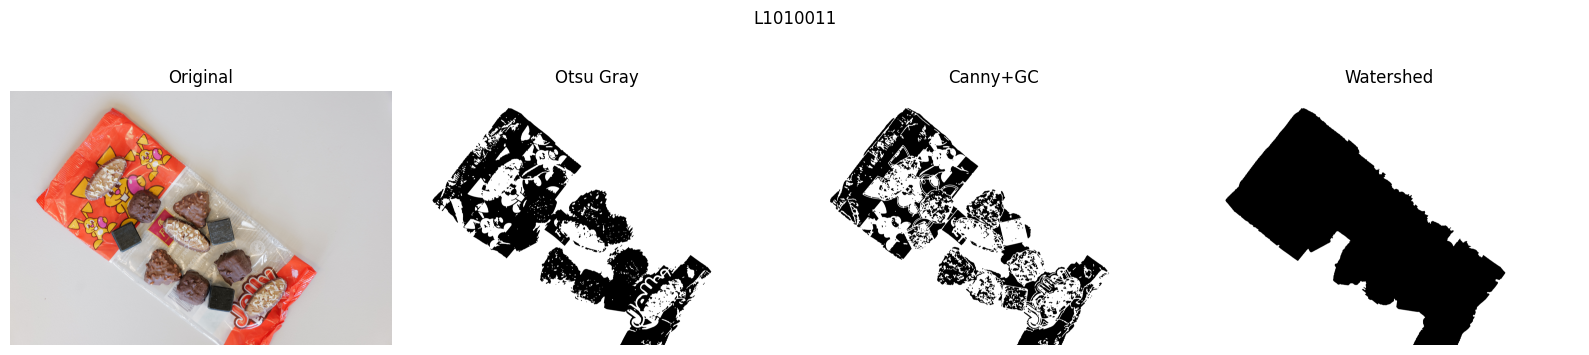

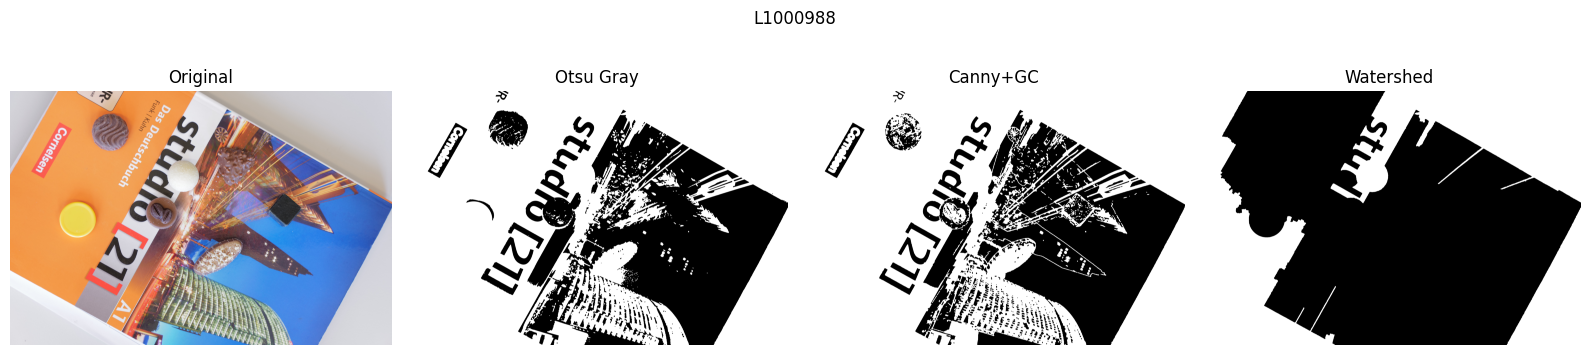

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

# Configuration
TEST_DIR = Path('test/test')
test_files = [
    "L1000757", "L1000935", "L1000782",
    "L1000840", "L1000883", "L1010011", "L1000988"
]

# Basic Otsu gray mask
def otsu_gray(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, m = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return m

# Canny-based edge mask combined with Otsu
def canny_grabcut(img):
    # initial Otsu
    mask = otsu_gray(img)
    # find edges
    edges = cv2.Canny(img, 50, 150)
    # prepare GrabCut mask: sure bg/fg
    gc_mask = np.where(mask > 0, cv2.GC_PR_FGD, cv2.GC_PR_BGD).astype('uint8')
    bgd, fgd = np.zeros((1,65), np.float64), np.zeros((1,65), np.float64)
    # run GrabCut
    cv2.grabCut(img, gc_mask, None, bgd, fgd, 5, cv2.GC_INIT_WITH_MASK)
    grab = np.where((gc_mask==cv2.GC_FGD)|(gc_mask==cv2.GC_PR_FGD),255,0).astype('uint8')
    # combine edges to refine boundaries
    refined = cv2.bitwise_or(grab, edges)
    return refined

# Watershed segmentation
def watershed_seg(img):
    # binary mask
    mask = otsu_gray(img)
    # noise removal
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    opening = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
    #closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=2)
    # sure background
    sure_bg = cv2.dilate(opening, kernel, iterations=3)
    # distance transform for sure foreground
    dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist, 0.4*dist.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    # unknown region
    unknown = cv2.subtract(sure_bg, sure_fg)
    # marker labelling
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown==255] = 0
    # apply watershed
    ws = cv2.watershed(img, markers)
    # watershed regions labelled -1 on boundaries
    seg = np.zeros(img.shape[:2], dtype=np.uint8)
    seg[ws > 1] = 255
    return seg

# Refine mask (morphology)
def refine(mask):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9,9))
    m = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    m = cv2.dilate(m, kernel, iterations=1)
    return m

methods = [
    ("Otsu Gray",    otsu_gray),
    ("Canny+GC",     canny_grabcut),
    ("Watershed",    watershed_seg),
]

# Plot results
for base in test_files:
    img_path = TEST_DIR/f"{base}.jpg"
    if not img_path.exists():
        img_path = TEST_DIR/f"{base}.JPG"
    img = cv2.imread(str(img_path))
    if img is None:
        continue

    plt.figure(figsize=(4*(len(methods)+1), 4))
    plt.subplot(1, len(methods)+1, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis('off')

    for i, (name, fn_seg) in enumerate(methods, start=2):
        raw = fn_seg(img)
        m = refine(raw)
        plt.subplot(1, len(methods)+1, i)
        plt.imshow(m, cmap='gray')
        plt.title(name)
        plt.axis('off')

    plt.suptitle(base)
    plt.tight_layout()
    plt.show()


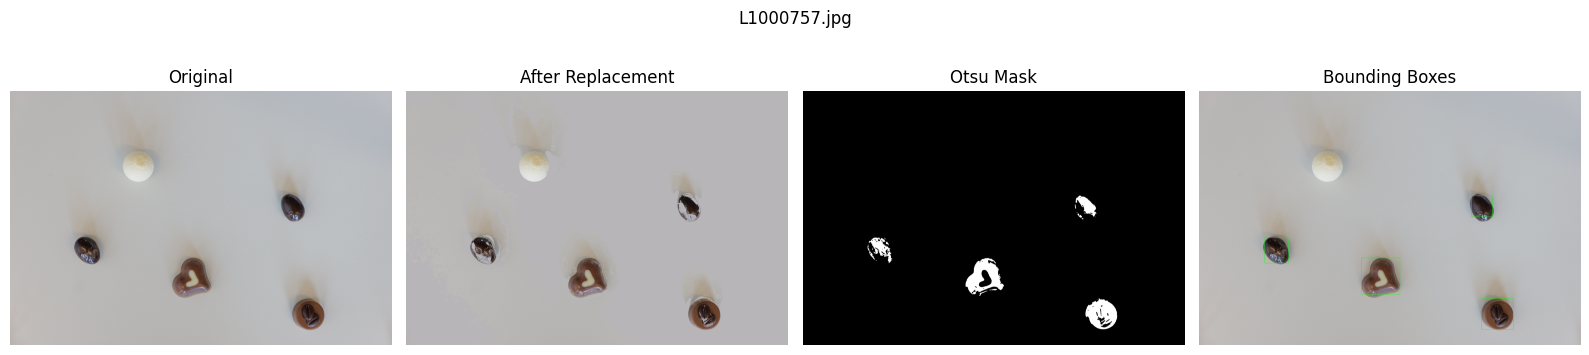

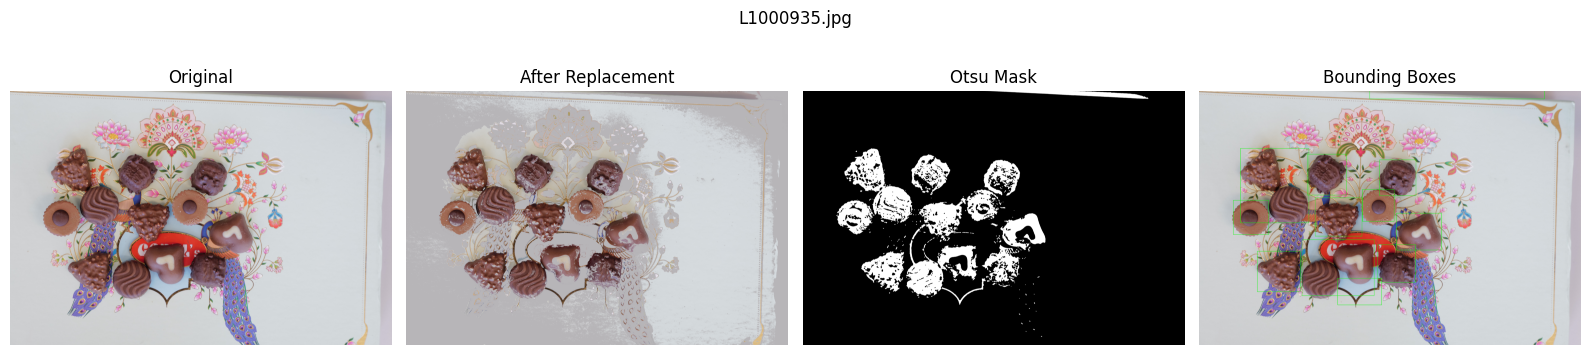

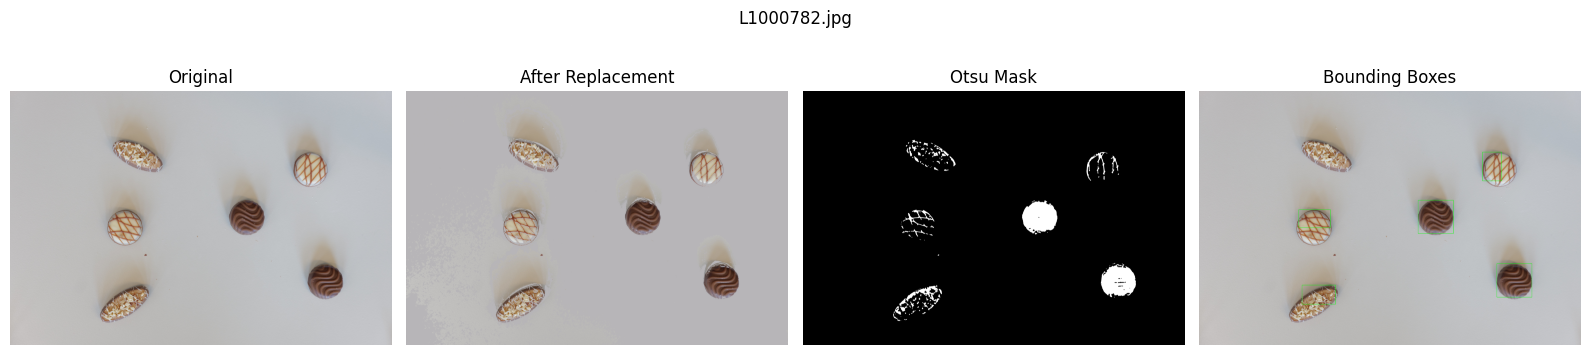

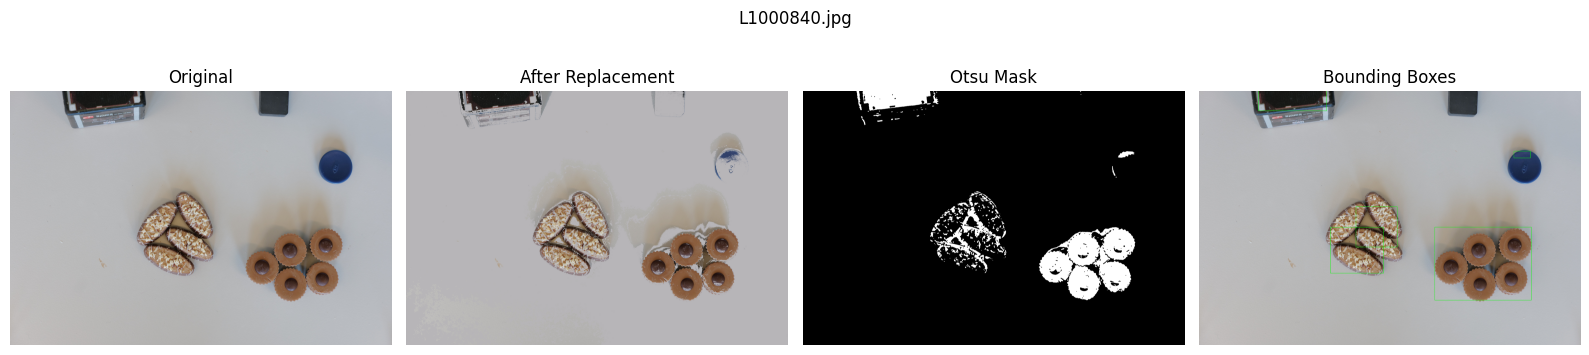

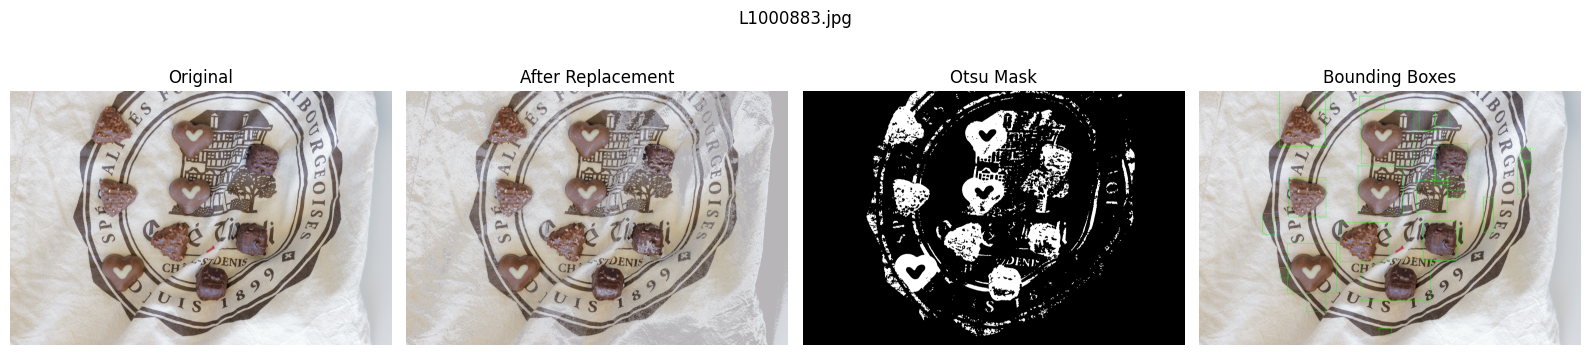

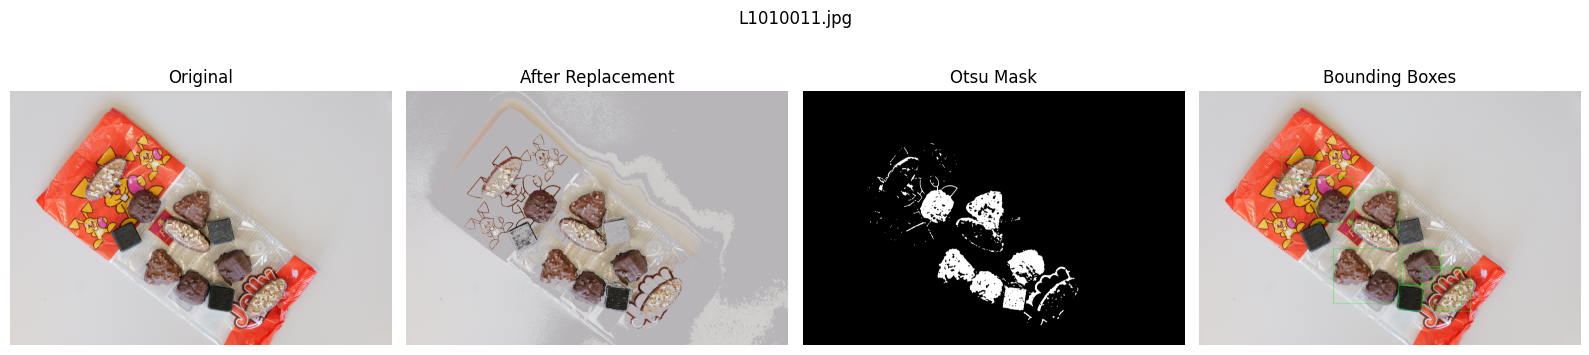

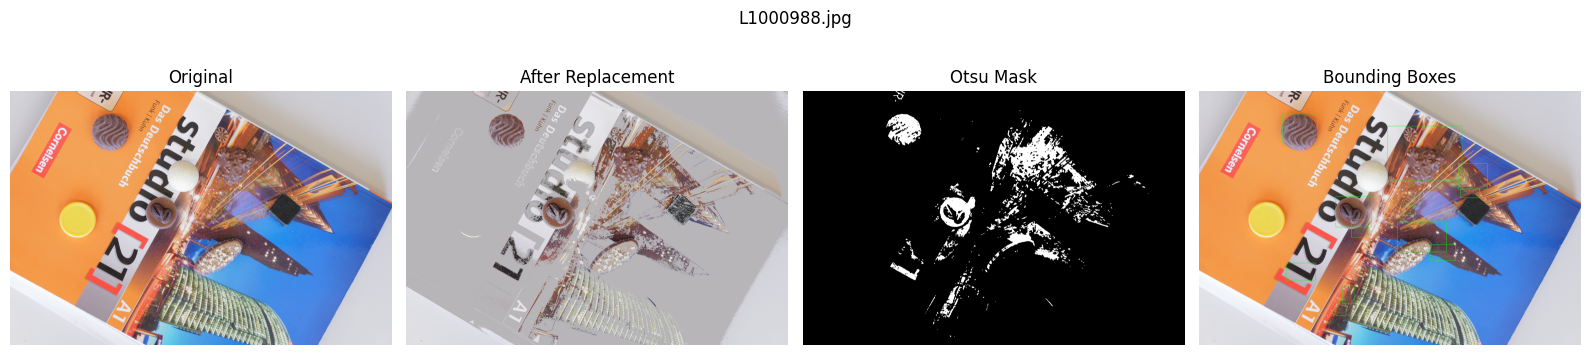

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
MIN_AREA = 10000
# 1) Configuration
TEST_DIR = Path('test/test')  # adjust if images are elsewhere
test_bases = [
    "L1000757", "L1000935", "L1000782",
    "L1000840", "L1000883", "L1010011", "L1000988"
]

# Color data (RGB tuples)
color_data = {
    "Amandina": [(180, 172, 152), (143, 96, 54), (195, 179, 128)],
    "Arabia": [(101, 61, 38), (50, 30, 23)],
    "Comtesse": [(225, 225, 217), (186, 172, 137)],
    "Crème Brulée": [(197, 188, 159), (148, 75, 32)],
    "Jelly Black": [(34, 23, 21), (70, 83, 125)],
    "Jelly Milk": [(86, 49, 30), (142, 135, 153)],
    "Jelly White": [(202, 193, 162), (228, 229, 223)],
    "Noblesse": [(138, 92, 59), (61, 37, 27)],
    "Noir Authentique": [(67, 37, 27), (118, 82, 58)],
    "Passion au Lait": [(94, 56, 35), (181, 175, 143), (134, 110, 112)],
    "Stracciatella": [(81, 53, 40), (139, 137, 142)],
    "Tentation Noir": [(75, 45, 35), (42, 30, 32), (103, 79, 79)],
    "Triangolo": [(99, 52, 32), (130, 97, 90), (67, 37, 27)],
}
replacement_color = (183, 181, 184)  # RGB

# 2) Mask creation functions
def create_combined_mask_rgb(img_rgb, color_data, tol=(15,15,15)):
    mask = np.zeros(img_rgb.shape[:2], dtype=np.uint8)
    for colors in color_data.values():
        for c in colors:
            diff = np.abs(img_rgb.astype(int) - np.array(c)[None,None,:])
            mask[np.all(diff <= tol, axis=2)] = 255
    return mask

def create_combined_mask_hsv(img_bgr, color_data, tol=(5,40,30)):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for colors in color_data.values():
        for c in colors:
            # convert RGB to HSV via BGR intermediary
            bgr = np.uint8([[[c[2], c[1], c[0]]]])
            hsv_ref = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)[0,0]
            # compute channel diffs
            diff = np.abs(hsv.astype(int) - hsv_ref[None,None,:])
            dh = np.minimum(diff[:,:,0], 180 - diff[:,:,0])
            ds, dv = diff[:,:,1], diff[:,:,2]
            mask[(dh <= tol[0]) & (ds <= tol[1]) & (dv <= tol[2])] = 255
    return mask

# 3) Otsu on preprocessed
def otsu_on_replacement(img_bgr):
    # RGB replacement
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mask_rgb = create_combined_mask_rgb(img_rgb, color_data, tol=(15,15,15))
    mask_hsv = create_combined_mask_hsv(img_bgr, color_data, tol=(5,40,30))
    combined = cv2.bitwise_or(mask_rgb, mask_hsv)
    # replace background
    result = img_rgb.copy()
    result[combined == 0] = replacement_color
    # grayscale + Otsu
    gray = cv2.cvtColor(result, cv2.COLOR_RGB2GRAY)
    _, otsu_mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    otsu_mask = cv2.bitwise_not(otsu_mask)
    # morphology
    # erosion
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    otsu_mask = cv2.erode(otsu_mask, kernel, iterations=1)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9,9))
    otsu_mask = cv2.morphologyEx(otsu_mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    otsu_mask = cv2.morphologyEx(otsu_mask, cv2.MORPH_OPEN, kernel, iterations=1)
    


    return result, otsu_mask

def draw_contours(img_bgr, mask):
    vis = img_bgr.copy()
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for c in cnts:
        if cv2.contourArea(c) < MIN_AREA:
            continue
        x,y,w,h = cv2.boundingRect(c)
        cv2.rectangle(vis, (x,y), (x+w, y+h), (0,255,0), 3)
    return vis


# 4) Iterate and plot
for base in test_bases:
    # load image
    img_path = TEST_DIR / f"{base}.jpg"
    if not img_path.exists():
        img_path = TEST_DIR / f"{base}.JPG"
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Missing: {base}")
        continue

    # preprocess + Otsu
    preproc, mask = otsu_on_replacement(img)
    contoured = draw_contours(img, mask)

    # display
    plt.figure(figsize=(16,4))
    plt.subplot(1,4,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original"); plt.axis('off')

    plt.subplot(1,4,2)
    plt.imshow(preproc)
    plt.title("After Replacement"); plt.axis('off')

    plt.subplot(1,4,3)
    plt.imshow(mask, cmap='gray')
    plt.title("Otsu Mask"); plt.axis('off')

    plt.subplot(1,4,4)
    plt.imshow(cv2.cvtColor(contoured, cv2.COLOR_BGR2RGB))
    plt.title("Bounding Boxes"); plt.axis('off')

    plt.suptitle(f"{base}.jpg")
    plt.tight_layout()
    plt.show()
